# Osprey vs DIA-NN Comparison

Comparison of Osprey v0.1.0 and DIA-NN 2.3.2 on 3 Astral HeLa DIA files with a ~1.57M precursor library.

- **DIA-NN 2.3.2**: 8 threads, i9-9900K
- **Osprey v0.1.0**: 10 threads, i9-9900K

## Figure 1: Search Time Comparison (Stacked Bar)

In [8]:
import re
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

DATA_DIR = Path("../example_test_data/astral")
OSPREY_LOG = DATA_DIR / "osprey_2026-03-26_214705.log"
DIANN_LOG = DATA_DIR / "DIANN-Output" / "report.log.txt"


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def parse_diann_ts(text: str) -> float:
    """Parse DIA-NN '[M:SS]' or '[MM:SS]' timestamp to minutes."""
    m = re.search(r"\[(\d+):(\d+)\]", text)
    if not m:
        return None
    return int(m.group(1)) + int(m.group(2)) / 60.0


def parse_osprey_ts(text: str) -> datetime:
    """Parse Osprey ISO timestamp to datetime."""
    m = re.search(r"\[(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2})Z", text)
    if not m:
        return None
    return datetime.fromisoformat(m.group(1))


def osprey_minutes_between(lines, start_pattern, end_pattern):
    """Minutes between two patterns in Osprey log."""
    t0 = t1 = None
    for line in lines:
        if t0 is None and re.search(start_pattern, line):
            t0 = parse_osprey_ts(line)
        if re.search(end_pattern, line):
            t1 = parse_osprey_ts(line)
    if t0 and t1:
        return (t1 - t0).total_seconds() / 60.0
    return 0.0


# ---------------------------------------------------------------------------
# Parse DIA-NN log
# ---------------------------------------------------------------------------

diann_lines = DIANN_LOG.read_text().splitlines()

# Find key timestamps
diann_ts = {}
for line in diann_lines:
    ts = parse_diann_ts(line)
    if ts is None:
        continue
    if "Loading spectral library" in line and "first-pass" not in line.lower() and "report-lib" not in line:
        diann_ts.setdefault("library_start", ts)
    if "Initialising library" in line and "library_init_done" not in diann_ts:
        diann_ts["library_init_done"] = ts
    # First pass starts with first file load
    if "File #1/3" in line and "first_pass_start" not in diann_ts:
        diann_ts["first_pass_start"] = ts
    if "File #2/3" in line and "file2_fp" not in diann_ts:
        diann_ts["file2_fp"] = ts
    if "File #3/3" in line and "file3_fp" not in diann_ts:
        diann_ts["file3_fp"] = ts
    # Cross-run (first pass)
    if "Cross-run analysis" in line and "crossrun1" not in diann_ts:
        diann_ts["crossrun1"] = ts
    # Spectral library saved (end of first pass)
    if "Spectral library saved" in line and "speclib_saved" not in diann_ts:
        diann_ts["speclib_saved"] = ts
    # Second pass
    if "Second pass" in line:
        diann_ts.setdefault("second_pass_start", ts)
    if "File #1/3" in line and "second_pass_start" in diann_ts and "sp_file1" not in diann_ts:
        diann_ts["sp_file1"] = ts
    if "File #2/3" in line and "second_pass_start" in diann_ts and "sp_file2" not in diann_ts:
        diann_ts["sp_file2"] = ts
    if "File #3/3" in line and "second_pass_start" in diann_ts and "sp_file3" not in diann_ts:
        diann_ts["sp_file3"] = ts
    # Cross-run (second pass)
    if "Cross-run analysis" in line:
        diann_ts["crossrun2"] = ts  # overwrite to get the last one

# Last timestamp
diann_last = 0
for line in reversed(diann_lines):
    ts = parse_diann_ts(line)
    if ts is not None:
        diann_last = ts
        break

# Categorize DIA-NN times (minutes)
# For DIA-NN, break down per-file time into calibration vs main search vs NN training
# by scanning for per-file sub-events
def diann_per_file_breakdown(lines, file_start_ts, file_end_ts):
    """Break a DIA-NN per-file block into calibration, search, NN training."""
    calibration = 0  # Loading + Pre-processing + Calibrating + RT/Peak/Scan window + mass accuracy
    search = 0       # Main search + Removing low confidence + Removing interfering
    modeling = 0     # Training neural networks + IDs + q-values + Quantification
    
    events = []
    in_range = False
    for line in lines:
        ts = parse_diann_ts(line)
        if ts is None:
            continue
        if abs(ts - file_start_ts) < 0.01:
            in_range = True
        if in_range:
            events.append((ts, line))
        if ts >= file_end_ts - 0.01 and in_range:
            break
    
    # Classify events
    phase_times = {"calib": 0, "search": 0, "model": 0}
    current_phase = "calib"
    for i, (ts, line) in enumerate(events):
        if "Main search" in line:
            current_phase = "search"
        elif "Training neural" in line:
            current_phase = "model"
        elif "Quantification" in line and "information" not in line:
            current_phase = "model"
        if i + 1 < len(events):
            dt = events[i + 1][0] - ts
            phase_times[current_phase] += dt
    
    return phase_times["calib"], phase_times["search"], phase_times["model"]


# DIA-NN first pass file boundaries
fp_file_ends = [
    diann_ts.get("file2_fp", diann_ts.get("crossrun1")),
    diann_ts.get("file3_fp", diann_ts.get("crossrun1")),
    diann_ts["crossrun1"],
]
fp_file_starts = [
    diann_ts["first_pass_start"],
    diann_ts.get("file2_fp"),
    diann_ts.get("file3_fp"),
]

fp_calib_total = fp_search_total = fp_model_total = 0
for s, e in zip(fp_file_starts, fp_file_ends):
    c, sr, m = diann_per_file_breakdown(diann_lines, s, e)
    fp_calib_total += c
    fp_search_total += sr
    fp_model_total += m

# DIA-NN second pass file boundaries
sp_file_starts = [diann_ts.get("sp_file1"), diann_ts.get("sp_file2"), diann_ts.get("sp_file3")]
sp_file_ends = [diann_ts.get("sp_file2"), diann_ts.get("sp_file3"), diann_ts["crossrun2"]]

sp_calib_total = sp_search_total = sp_model_total = 0
for s, e in zip(sp_file_starts, sp_file_ends):
    if s is not None and e is not None:
        c, sr, m = diann_per_file_breakdown(diann_lines, s, e)
        sp_calib_total += c
        sp_search_total += sr
        sp_model_total += m

diann_setup = diann_ts["first_pass_start"] - diann_ts.get("library_start", 0)
diann_calib = fp_calib_total + sp_calib_total
diann_search = fp_search_total + sp_search_total
diann_modeling = fp_model_total + sp_model_total
diann_second_pass_overhead = (
    diann_ts["crossrun1"] - fp_file_ends[-1]  # first cross-run
    + (diann_ts.get("sp_file1", diann_ts["crossrun1"]) - diann_ts["crossrun1"])  # speclib gen + reload
)
diann_crossrun = diann_last - diann_ts["crossrun2"]  # final cross-run to end

# Combine into final categories matching the figure
diann_times = {
    "Setup & library":          diann_setup,
    "Calibration & file loading": diann_calib,
    "Main search":              diann_search,
    "Statistical modeling / FDR": diann_modeling,
    "Second pass / refinement": diann_second_pass_overhead + sp_calib_total + sp_search_total + sp_model_total,
    "Cross-run & output":       diann_crossrun + (diann_ts["crossrun1"] - fp_file_ends[-1]),
}

# Recalculate more cleanly to avoid double-counting
# Setup: library load + FASTA + init
diann_times["Setup & library"] = diann_ts["first_pass_start"] - 0  # from [0:00] to first file

# First-pass per-file: calibration, search, modeling  
diann_times["Calibration & file loading"] = fp_calib_total
diann_times["Main search"] = fp_search_total
diann_times["Statistical modeling / FDR"] = fp_model_total

# Second pass = everything from cross-run1 to crossrun2 
diann_times["Second pass / refinement"] = diann_ts["crossrun2"] - diann_ts["crossrun1"]

# Cross-run & output = final cross-run analysis
diann_times["Cross-run & output"] = diann_last - diann_ts["crossrun2"]

diann_total = sum(diann_times.values())

print("DIA-NN timing breakdown (minutes):")
for k, v in diann_times.items():
    print(f"  {k}: {v:.1f}")
print(f"  TOTAL: {diann_total:.1f}")

DIA-NN timing breakdown (minutes):
  Setup & library: 1.2
  Calibration & file loading: 3.2
  Main search: 8.7
  Statistical modeling / FDR: 13.7
  Second pass / refinement: 9.7
  Cross-run & output: 2.7
  TOTAL: 39.2


In [9]:
# ---------------------------------------------------------------------------
# Parse Osprey log
# ---------------------------------------------------------------------------

osprey_lines = OSPREY_LOG.read_text().splitlines()

# Find key timestamps
osprey_events = []
for line in osprey_lines:
    ts = parse_osprey_ts(line)
    if ts is not None:
        osprey_events.append((ts, line))

t0 = osprey_events[0][0]  # first timestamp = start

def osprey_find_ts(pattern):
    """Find first timestamp matching pattern."""
    for ts, line in osprey_events:
        if re.search(pattern, line):
            return ts
    return None

def osprey_find_last_ts(pattern):
    """Find last timestamp matching pattern."""
    result = None
    for ts, line in osprey_events:
        if re.search(pattern, line):
            result = ts
    return result

def minutes_from_start(ts):
    return (ts - t0).total_seconds() / 60.0

# Setup & library: start to first "Processing file 1/3"
setup_end = osprey_find_ts(r"Processing file 1/3")

# Per-file phases: for each file, find calibration and main search boundaries
file_starts = []
file_calib_ends = []  # when "Coelution search:" appears (start of main search)
file_search_ends = []  # when "Wrote.*scores.*parquet" appears

for i in range(1, 4):
    fs = osprey_find_ts(rf"Processing file {i}/3")
    file_starts.append(fs)

# For each file block, find the coelution search start and parquet write
calib_total = 0
search_total = 0
for i in range(3):
    block_start = file_starts[i]
    block_end = file_starts[i + 1] if i + 1 < 3 else osprey_find_ts(r"Coelution analysis complete")
    
    # Find first "Coelution search:" (not calibration) in this block = main search start
    search_start = None
    for ts, line in osprey_events:
        if ts < block_start or ts > block_end:
            continue
        if "Coelution search:" in line and "calibration" not in line and "spectra in" in line:
            # This is the full search, not calibration scoring
            if "3131286 library entries" in line:
                search_start = ts
                break
    
    # Search end = parquet write
    search_end = None
    for ts, line in osprey_events:
        if ts < block_start or ts > block_end:
            continue
        if "Wrote" in line and "scores" in line and "parquet" in line:
            search_end = ts
            break
    
    if search_start and search_end:
        calib_total += (search_start - block_start).total_seconds() / 60.0
        search_total += (search_end - search_start).total_seconds() / 60.0

# FDR: from "Coelution analysis complete" to "Multi-charge consensus" or reconciliation
fdr_start = osprey_find_ts(r"Running percolator FDR control on coelution")
fdr_end = osprey_find_ts(r"Multi-charge consensus:")

# Second pass (reconciliation + re-scoring + 2nd FDR)
second_pass_start = fdr_end
second_pass_end = osprey_find_ts(r"Experiment-level results.*from 46488")
if second_pass_end is None:
    # Find last experiment-level results line
    second_pass_end = osprey_find_last_ts(r"Experiment-level results")

# Output
output_start = second_pass_end
output_end = osprey_events[-1][0]

osprey_times = {
    "Setup & library":            (setup_end - t0).total_seconds() / 60.0,
    "Calibration & file loading": calib_total,
    "Main search":                search_total,
    "Statistical modeling / FDR": (fdr_end - fdr_start).total_seconds() / 60.0,
    "Second pass / refinement":   (second_pass_end - second_pass_start).total_seconds() / 60.0,
    "Cross-run & output":         (output_end - output_start).total_seconds() / 60.0,
}

osprey_total = sum(osprey_times.values())

print("Osprey timing breakdown (minutes):")
for k, v in osprey_times.items():
    print(f"  {k}: {v:.1f}")
print(f"  TOTAL: {osprey_total:.1f}")

Osprey timing breakdown (minutes):
  Setup & library: 0.1
  Calibration & file loading: 5.6
  Main search: 12.3
  Statistical modeling / FDR: 2.6
  Second pass / refinement: 7.1
  Cross-run & output: 0.8
  TOTAL: 28.6


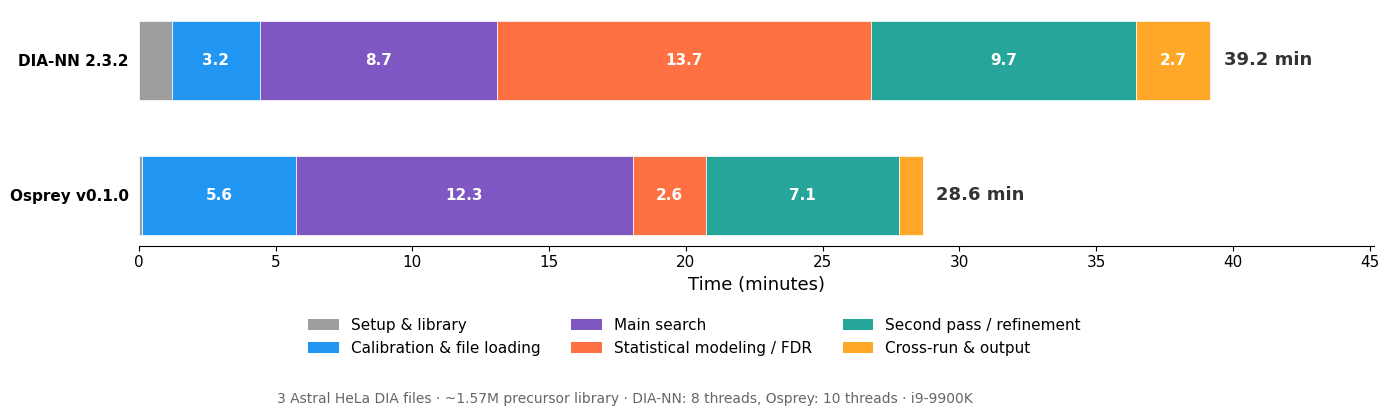

In [10]:
# ---------------------------------------------------------------------------
# Stacked horizontal bar chart
# ---------------------------------------------------------------------------

categories = [
    "Setup & library",
    "Calibration & file loading",
    "Main search",
    "Statistical modeling / FDR",
    "Second pass / refinement",
    "Cross-run & output",
]

colors = {
    "Setup & library":            "#9E9E9E",  # gray
    "Calibration & file loading": "#2196F3",  # blue
    "Main search":                "#7E57C2",  # purple
    "Statistical modeling / FDR": "#FF7043",  # orange
    "Second pass / refinement":   "#26A69A",  # teal
    "Cross-run & output":         "#FFA726",  # gold
}

tools = ["DIA-NN 2.3.2", "Osprey v0.1.0"]
all_times = [diann_times, osprey_times]
totals = [diann_total, osprey_total]

fig, ax = plt.subplots(figsize=(14, 4))

y_positions = [1.2, 0]
bar_height = 0.7

for idx, (tool, times, total) in enumerate(zip(tools, all_times, totals)):
    left = 0
    y = y_positions[idx]
    for cat in categories:
        val = times.get(cat, 0)
        if val < 0.05:
            left += val
            continue
        bar = ax.barh(y, val, left=left, height=bar_height,
                      color=colors[cat], edgecolor="white", linewidth=0.5)
        # Label on bar if wide enough
        if val >= 1.5:
            ax.text(left + val / 2, y, f"{val:.1f}",
                    ha="center", va="center", fontsize=11, fontweight="bold",
                    color="white")
        left += val
    # Total label
    ax.text(left + 0.5, y, f"{total:.1f} min", ha="left", va="center",
            fontsize=13, fontweight="bold", color="#333333")

ax.set_yticks(y_positions)
ax.set_yticklabels(tools, fontsize=14, fontweight="bold")
ax.set_xlabel("Time (minutes)", fontsize=13)
ax.set_xlim(0, max(totals) + 6)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(left=False, labelsize=11)

# Legend below
legend_handles = [plt.Rectangle((0, 0), 1, 1, fc=colors[c]) for c in categories]
ax.legend(legend_handles, categories, loc="upper center",
          bbox_to_anchor=(0.45, -0.25), ncol=3, frameon=False, fontsize=11)

# Subtitle
fig.text(0.45, -0.02,
         "3 Astral HeLa DIA files \u00b7 ~1.57M precursor library \u00b7 DIA-NN: 8 threads, Osprey: 10 threads \u00b7 i9-9900K",
         ha="center", fontsize=10, color="#666666")

plt.tight_layout()
plt.savefig("05_search_time_comparison.png", dpi=200, bbox_inches="tight",
            facecolor="white", pad_inches=0.3)
plt.show()

## Figure 2: Precursor Overlap (UpSet Plot)

Compare experiment-level passing precursors from Osprey and DIA-NN, broken down by which files each precursor was detected in.

In [11]:
import pandas as pd
import sqlite3

# ---------------------------------------------------------------------------
# Load DIA-NN results
# ---------------------------------------------------------------------------

diann_df = pd.read_parquet(DATA_DIR / "DIANN-Output" / "report.parquet")

# Filter to 1% global (experiment-level) FDR, non-decoy
diann_pass = diann_df[(diann_df["Global.Q.Value"] <= 0.01) & (diann_df["Decoy"] == 0)].copy()

# Precursor key: stripped sequence + charge (tool-agnostic)
diann_pass["precursor_key"] = (
    diann_pass["Stripped.Sequence"] + "/" + diann_pass["Precursor.Charge"].astype(str)
)

# Short file names for display
run_names = sorted(diann_pass["Run"].unique())
file_short = {r: r.split("_")[-1] for r in run_names}  # e.g. "49", "55", "60"
diann_pass["file_short"] = diann_pass["Run"].map(file_short)

print(f"DIA-NN: {diann_pass['precursor_key'].nunique()} unique precursors passing 1% global FDR")
for r in run_names:
    n = diann_pass[diann_pass["Run"] == r]["precursor_key"].nunique()
    print(f"  {file_short[r]}: {n} precursors")

# ---------------------------------------------------------------------------
# Load Osprey results
# ---------------------------------------------------------------------------

conn = sqlite3.connect(str(DATA_DIR / "ospreyoutput.blib"))

# RefSpectra = experiment-level passing precursors
osprey_ref = pd.read_sql("SELECT id, peptideSeq, precursorCharge, peptideModSeq FROM RefSpectra", conn)
osprey_ref["precursor_key"] = osprey_ref["peptideSeq"] + "/" + osprey_ref["precursorCharge"].astype(str)

# SpectrumSourceFiles for file mapping
source_files = pd.read_sql("SELECT id, fileName FROM SpectrumSourceFiles", conn)
source_file_map = dict(zip(source_files["id"], source_files["fileName"]))

# RetentionTimes: retentionTime IS NOT NULL means passed run-level FDR in that file
osprey_rt = pd.read_sql(
    "SELECT RefSpectraID, SpectrumSourceID, retentionTime, startTime, endTime "
    "FROM RetentionTimes WHERE retentionTime IS NOT NULL",
    conn,
)
conn.close()

# Map source IDs to short file names
osprey_rt["file_name"] = osprey_rt["SpectrumSourceID"].map(source_file_map)
osprey_rt["file_short"] = osprey_rt["file_name"].apply(lambda x: x.split("_")[-1].replace(".mzML", ""))

# Join to get precursor keys
osprey_rt = osprey_rt.merge(osprey_ref[["id", "precursor_key"]], left_on="RefSpectraID", right_on="id")

print(f"\nOsprey: {osprey_ref['precursor_key'].nunique()} unique precursors passing 1% experiment FDR")
for fs in sorted(osprey_rt["file_short"].unique()):
    n = osprey_rt[osprey_rt["file_short"] == fs]["precursor_key"].nunique()
    print(f"  {fs}: {n} precursors (run-level FDR passing)")

DIA-NN: 145654 unique precursors passing 1% global FDR
  49: 140136 precursors
  55: 139819 precursors
  60: 138979 precursors

Osprey: 138770 unique precursors passing 1% experiment FDR
  49: 130121 precursors (run-level FDR passing)
  55: 130260 precursors (run-level FDR passing)
  60: 128804 precursors (run-level FDR passing)


In [12]:
# ---------------------------------------------------------------------------
# Build per-file sets for UpSet plot
# ---------------------------------------------------------------------------
from itertools import combinations

file_ids = sorted(set(osprey_rt["file_short"].unique()) | set(diann_pass["file_short"].unique()))

# Build sets: {precursor_key} for each tool x file combination
sets = {}
for fs in file_ids:
    sets[f"DIA-NN ({fs})"] = set(
        diann_pass[diann_pass["file_short"] == fs]["precursor_key"]
    )
    sets[f"Osprey ({fs})"] = set(
        osprey_rt[osprey_rt["file_short"] == fs]["precursor_key"]
    )

# Also experiment-level sets (union across files)
diann_all = set(diann_pass["precursor_key"])
osprey_all = set(osprey_ref["precursor_key"])

print(f"Experiment-level overlap:")
print(f"  DIA-NN only: {len(diann_all - osprey_all):,}")
print(f"  Osprey only: {len(osprey_all - diann_all):,}")
print(f"  Shared:      {len(diann_all & osprey_all):,}")
print(f"  Union:       {len(diann_all | osprey_all):,}")

Experiment-level overlap:
  DIA-NN only: 26,194
  Osprey only: 19,310
  Shared:      119,460
  Union:       164,964


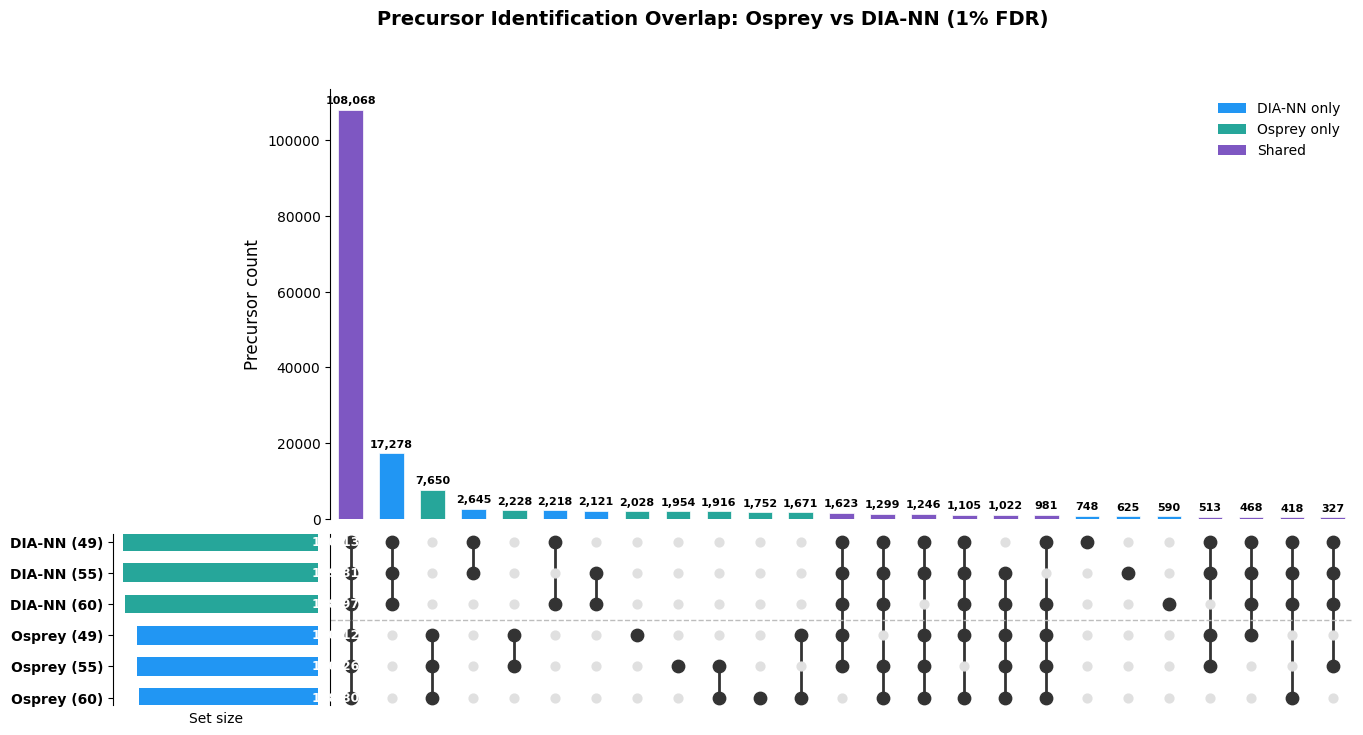

In [13]:
# ---------------------------------------------------------------------------
# UpSet plot (manual implementation with matplotlib)
# ---------------------------------------------------------------------------

# Define the set labels in display order (DIA-NN files first, then Osprey files)
set_labels = [f"DIA-NN ({fs})" for fs in file_ids] + [f"Osprey ({fs})" for fs in file_ids]
n_sets = len(set_labels)

# All precursors in the universe
universe = set()
for s in sets.values():
    universe |= s

# Assign each precursor to its membership tuple
membership = {}
for prec in universe:
    key = tuple(prec in sets[label] for label in set_labels)
    membership.setdefault(key, 0)
    membership[key] += 1

# Sort intersections by size (descending), take top N
sorted_intersections = sorted(membership.items(), key=lambda x: x[1], reverse=True)
top_n = 25  # show top 25 intersections
top_intersections = sorted_intersections[:top_n]

# Color-code bars: blue for DIA-NN only, teal for Osprey only, purple for shared
def bar_color(key):
    diann_any = any(key[:3])
    osprey_any = any(key[3:])
    if diann_any and osprey_any:
        return "#7E57C2"  # purple = shared
    elif diann_any:
        return "#2196F3"  # blue = DIA-NN only
    else:
        return "#26A69A"  # teal = Osprey only

fig = plt.figure(figsize=(16, 8))

# Layout: left = set size bars, right = (top: intersection bars, bottom: dot matrix)
gs = fig.add_gridspec(2, 2, height_ratios=[2.5, 1], width_ratios=[1, 5],
                      hspace=0.05, wspace=0.02)
ax_bar = fig.add_subplot(gs[0, 1])
ax_dot = fig.add_subplot(gs[1, 1])
ax_sizes = fig.add_subplot(gs[1, 0])

x = np.arange(len(top_intersections))
counts = [c for _, c in top_intersections]
bar_colors = [bar_color(k) for k, _ in top_intersections]

ax_bar.bar(x, counts, color=bar_colors, width=0.6, edgecolor="white", linewidth=0.5)
for i, c in enumerate(counts):
    ax_bar.text(i, c + max(counts) * 0.01, f"{c:,}", ha="center", va="bottom",
                fontsize=8, fontweight="bold", rotation=0)
ax_bar.set_ylabel("Precursor count", fontsize=12)
ax_bar.set_xlim(-0.5, len(top_intersections) - 0.5)
ax_bar.set_xticks([])
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
ax_bar.spines["bottom"].set_visible(False)

# Dot matrix
for i, (key, _) in enumerate(top_intersections):
    for j, is_member in enumerate(key):
        if is_member:
            ax_dot.scatter(i, n_sets - 1 - j, color="#333333", s=80, zorder=3)
        else:
            ax_dot.scatter(i, n_sets - 1 - j, color="#E0E0E0", s=40, zorder=2)
    # Connect active dots with a line
    active = [n_sets - 1 - j for j, m in enumerate(key) if m]
    if len(active) > 1:
        ax_dot.plot([i, i], [min(active), max(active)], color="#333333",
                    linewidth=2, zorder=1)

ax_dot.set_yticks([])
ax_dot.set_xlim(-0.5, len(top_intersections) - 0.5)
ax_dot.set_xticks([])
ax_dot.spines["top"].set_visible(False)
ax_dot.spines["right"].set_visible(False)
ax_dot.spines["bottom"].set_visible(False)

# Add horizontal gridlines between DIA-NN and Osprey groups
ax_dot.axhline(y=2.5, color="#BDBDBD", linewidth=1, linestyle="--")

# Set size horizontal bars (left panel, aligned with dot matrix rows)
set_sizes = [len(sets[label]) for label in reversed(set_labels)]
y_pos = range(n_sets)
bar_colors_sets = ["#2196F3"] * 3 + ["#26A69A"] * 3
ax_sizes.barh(y_pos, set_sizes, color=bar_colors_sets, height=0.6)
for i, s in enumerate(set_sizes):
    ax_sizes.text(max(set_sizes) * 0.03, i, f"{s:,}", va="center", ha="left",
                  fontsize=9, fontweight="bold", color="white")
ax_sizes.set_yticks(range(n_sets))
ax_sizes.set_yticklabels(list(reversed(set_labels)), fontsize=10, fontweight="bold")
ax_sizes.set_xticks([])
ax_sizes.set_ylim(ax_dot.get_ylim())
ax_sizes.invert_xaxis()
ax_sizes.spines["top"].set_visible(False)
ax_sizes.spines["right"].set_visible(False)
ax_sizes.spines["bottom"].set_visible(False)
ax_sizes.set_xlabel("Set size", fontsize=10)

# Hide top-left corner
ax_empty = fig.add_subplot(gs[0, 0])
ax_empty.axis("off")

# Legend for bar colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="DIA-NN only"),
    Patch(facecolor="#26A69A", label="Osprey only"),
    Patch(facecolor="#7E57C2", label="Shared"),
]
ax_bar.legend(handles=legend_elements, loc="upper right", frameon=False, fontsize=10)

fig.suptitle("Precursor Identification Overlap: Osprey vs DIA-NN (1% FDR)",
             fontsize=14, fontweight="bold", y=0.98)

plt.savefig("05_upset_precursor_overlap.png", dpi=200, bbox_inches="tight",
            facecolor="white", pad_inches=0.3)
plt.show()

## Figure 3: RT Correlation for Shared Precursors

For precursors identified by both tools in each file, compare their apex retention times. If both tools correctly identify the same precursors, their RTs should fall on the diagonal.

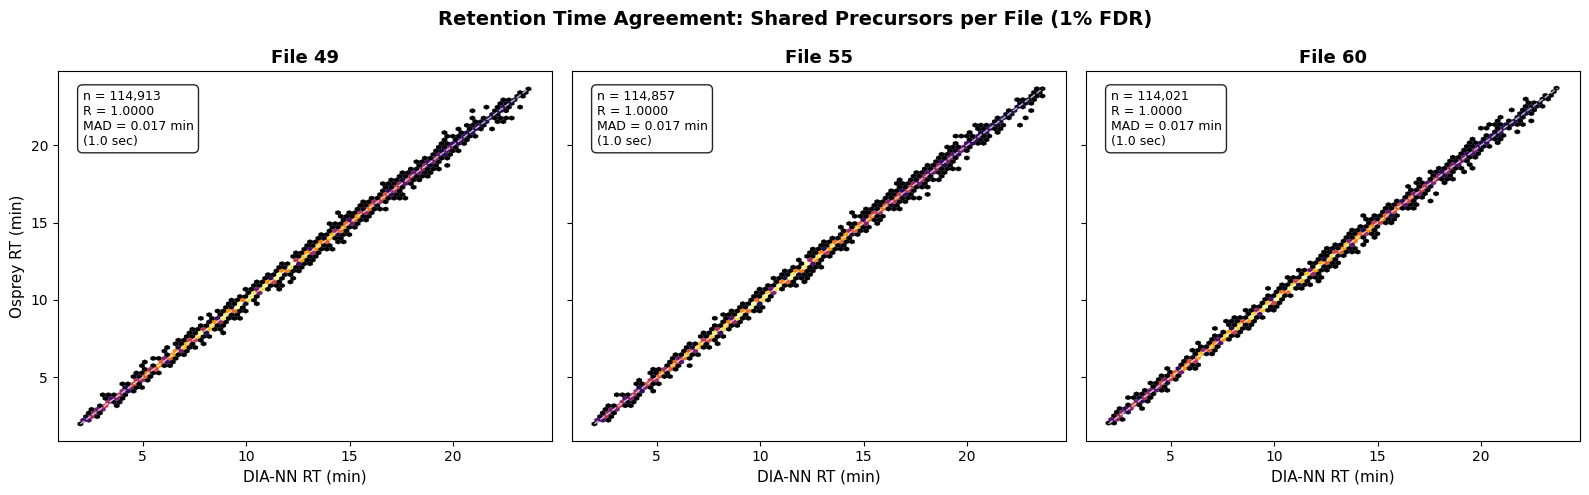

In [14]:
# ---------------------------------------------------------------------------
# RT scatter plots: shared precursors per file
# ---------------------------------------------------------------------------
from scipy import stats

# Build per-file RT tables
# DIA-NN: precursor_key -> RT per file (use run-level Q.Value <= 0.01)
diann_rt_by_file = {}
for fs in file_ids:
    subset = diann_pass[diann_pass["file_short"] == fs][["precursor_key", "RT"]].copy()
    # If duplicates (shouldn't be), take the one with best evidence
    subset = subset.drop_duplicates(subset="precursor_key", keep="first")
    diann_rt_by_file[fs] = subset.set_index("precursor_key")["RT"]

# Osprey: precursor_key -> retentionTime per file (already filtered to non-NULL)
osprey_rt_by_file = {}
for fs in file_ids:
    subset = osprey_rt[osprey_rt["file_short"] == fs][["precursor_key", "retentionTime"]].copy()
    subset = subset.drop_duplicates(subset="precursor_key", keep="first")
    osprey_rt_by_file[fs] = subset.set_index("precursor_key")["retentionTime"]

# Create 1x3 scatter plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for idx, fs in enumerate(file_ids):
    ax = axes[idx]

    # Find shared precursors for this file
    shared_keys = set(diann_rt_by_file[fs].index) & set(osprey_rt_by_file[fs].index)
    shared_keys = sorted(shared_keys)

    diann_rts = diann_rt_by_file[fs].loc[shared_keys].values
    osprey_rts = osprey_rt_by_file[fs].loc[shared_keys].values

    # Density scatter using hexbin
    hb = ax.hexbin(diann_rts, osprey_rts, gridsize=80, cmap="inferno",
                   mincnt=1, linewidths=0.1)

    # Diagonal reference line
    rt_min = min(diann_rts.min(), osprey_rts.min())
    rt_max = max(diann_rts.max(), osprey_rts.max())
    ax.plot([rt_min, rt_max], [rt_min, rt_max], "w--", linewidth=1, alpha=0.7)

    # Stats
    r, _ = stats.pearsonr(diann_rts, osprey_rts)
    rt_diff = osprey_rts - diann_rts
    median_diff = np.median(np.abs(rt_diff))

    ax.set_title(f"File {fs}", fontsize=13, fontweight="bold")
    ax.set_xlabel("DIA-NN RT (min)", fontsize=11)
    if idx == 0:
        ax.set_ylabel("Osprey RT (min)", fontsize=11)

    # Annotation box
    textstr = (f"n = {len(shared_keys):,}\n"
               f"R = {r:.4f}\n"
               f"MAD = {median_diff:.3f} min\n"
               f"({median_diff * 60:.1f} sec)")
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85))

fig.suptitle("Retention Time Agreement: Shared Precursors per File (1% FDR)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("05_rt_scatter_comparison.png", dpi=200, bbox_inches="tight",
            facecolor="white", pad_inches=0.3)
plt.show()